# Setup

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
from sklearn import tree
from sklearn.model_selection import train_test_split
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss

# Read Data

In [2]:
folder_path = '../data/extracted_signals/'
data = []
file_name = []
for filename in glob.glob(os.path.join(folder_path, '*.npy')):
    with open(filename, 'r') as f:
        data.append(np.load(filename))
        file_name.append(filename)
#data = np.load("../data/extracted_signals/220516_No contraction videos.npy")
print(f'Nr of files: {len(data)}')

Nr of files: 15


In [3]:
idx_weak = []
idx_strong = []
idx_no= []
for n, file in enumerate(file_name):
    if "Weak" in file:
        print("weak", file)
        idx_weak.append(n)
    elif "Strong" in file:
        print("strong", file)
        idx_strong.append(n)
    else:
        print("no", file)
        idx_no.append(n)

weak ../data/extracted_signals/Weak contraction.lif - O1443_1b.npy
no ../data/extracted_signals/220516_No contraction videos.lif - O1319_3a.npy
no ../data/extracted_signals/220516_No contraction videos.lif - O1445_2a.npy
weak ../data/extracted_signals/Weak contraction.lif - O1318_1b.npy
strong ../data/extracted_signals/Strong contraction.lif - O1466_2a.npy
no ../data/extracted_signals/220516_No contraction videos.lif - O1463_1b.npy
strong ../data/extracted_signals/Strong contraction.lif - O1468_1b.npy
strong ../data/extracted_signals/Strong contraction.lif - O1319_1a.npy
no ../data/extracted_signals/220516_No contraction videos.lif - O1450_2 curare II.npy
weak ../data/extracted_signals/Weak contraction.lif - O1318_2a.npy
no ../data/extracted_signals/220516_No contraction videos.lif - O1498_1a curare.npy
strong ../data/extracted_signals/Strong contraction.lif - O1464_2a.npy
weak ../data/extracted_signals/Weak contraction.lif - O1301_3a.npy
strong ../data/extracted_signals/Strong contrac

In [4]:
data_weak = [data[i] for i in idx_weak]
data_strong = [data[i] for i in idx_strong]
data_no = [data[i] for i in idx_no]

In [5]:
data_weak[0].shape

(10, 1509)

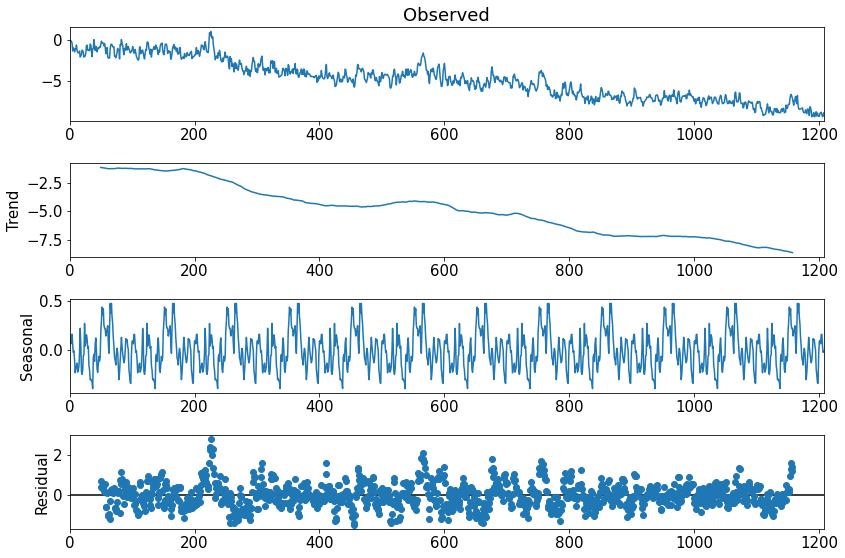

In [23]:
from statsmodels.tsa.seasonal import seasonal_decompose
plt.rc('figure',figsize=(12,8))
plt.rc('font',size=15)
result = seasonal_decompose(data_strong[0][1],model='additive',period=100)
fig = result.plot()

In [6]:
df = pd.DataFrame()
for i in range(len(data_no)):
    for j in range(data_no[i].shape[0]):
        df = df.append({'ts': data_no[i][j], 'label': 0, 'signal': 'weak'}, ignore_index=True)
for i in range(len(data_weak)):
    for j in range(data_weak[i].shape[0]):
        df = df.append({'ts': data_weak[i][j], 'label': 1, 'signal': 'weak'}, ignore_index=True)
for i in range(len(data_strong)):
    for j in range(data_strong[i].shape[0]):
        df = df.append({'ts': data_strong[i][j], 'label': 2, 'signal': 'weak'}, ignore_index=True)

In [7]:
df

,label,signal,ts
0,0.0,weak,"[0.0, 0.4273504273504187, 0.4273504273504187, ..."
1,0.0,weak,"[0.0, 0.2624434389140191, 0.2070588235294082, ..."
2,0.0,weak,"[0.0, 0.7047619047619094, 0.7047619047619094, ..."
3,0.0,weak,"[0.0, 0.6408045977011483, 0.6472148541113967, ..."
4,0.0,weak,"[0.0, 0.5827586206896456, 0.5862068965517153, ..."
...,...,...,...
145,2.0,weak,"[0.0, 0.04000000000000625, 0.00666666666667481..."
146,2.0,weak,"[0.0, 0.035714285714291805, -0.052910052910050..."
147,2.0,weak,"[0.0, 0.030788177339900358, 0.0, 0.13793103448..."
148,2.0,weak,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.06666666666667709,..."


https://neptune.ai/blog/anomaly-detection-in-time-series

In [41]:
df['ts'][0]

array([ 0.        ,  0.42735043,  0.42735043, ..., -2.06868132,
       -1.90598291, -1.92582418])

In [37]:
X_train, X_test, y_train, y_test = train_test_split(df['ts'], df['label'], test_size=0.33, random_state=42)

In [39]:
X_train

96     [0.0, 0.07359307359307365, 0.20454545454545325...
105    [0.0, -0.3859649122806985, -0.5686274509803866...
66     [0.0, 0.0, 0.0, 0.15789473684210975, 0.2972972...
0      [0.0, 0.4273504273504187, 0.4273504273504187, ...
122    [0.0, -0.5584415584415581, -0.6100386100386146...
                             ...                        
71     [0.0, -0.0799999999999983, -0.0676923076923117...
106    [0.0, -0.2727272727272805, -0.661779081133929,...
14     [0.0, -0.051282051282043994, 0.0, 0.0, 0.0, 0....
92     [0.0, 0.013833992094859582, -0.012681159420282...
102    [0.0, -0.418242491657395, -0.6627565982404775,...
Name: ts, Length: 100, dtype: object

In [38]:
clf = tree.DecisionTreeClassifier()
clf = clf.fit(X_train, y_train)

ValueError: setting an array element with a sequence.